In [9]:
import os, sys
import numpy as np
import pandas as pd
import skimage as ski
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier

In [10]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

from src.split_data import split_data
from feature_A import compute_asymmetry
from feature_B import border_calc
from feature_C import extract_color_features

cancerous = {"BCC", "SCC", "MEL"}

def make_features_labels(df, extra_drops=()):
    drops = ["img_id", "diagnostic", "Unnamed: 0", *extra_drops]
    features = df.drop(columns=drops, errors="ignore").select_dtypes(include="number")
    labels = np.where(df["diagnostic"].isin(cancerous), "cancerous", "non-cancerous")
    return features, labels

def make_forest(seed=6, n_estimators=200, max_depth=None):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced",
        random_state=seed,
    )

def extract_features(df, img_dir, mask_dir, img_prefix=""):
    asymmetry_features, border_features, color_features = [], [], []
    for img_id in df["img_id"]:
        name, ext = os.path.splitext(os.path.basename(img_id))
        img_path  = os.path.join(img_dir,  img_prefix + img_id)
        mask_path = os.path.join(mask_dir, f"{name}_mask{ext}")

        img = ski.io.imread(img_path)
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]
        img = ski.transform.resize(img, (255, 255))

        mask = ski.io.imread(mask_path)
        mask = ski.transform.resize(mask, (255, 255), preserve_range=True)
        if mask.ndim == 3:
            mask = ski.color.rgb2gray(mask) > 0.5
        else:
            mask = mask > 0.5

        asymmetry_features.append(compute_asymmetry(mask))
        border_features.append(border_calc(mask))
        color_features.append(extract_color_features(img, mask))

    return pd.concat([
        df.reset_index(drop=True),
        pd.DataFrame(asymmetry_features),
        pd.DataFrame(border_features),
        pd.DataFrame(color_features),
    ], axis=1)

In [11]:
clean_dir = os.path.join(ROOT, "data", "imgs_clean")
mask_dir  = os.path.join(ROOT, "data", "masks")
out_csv   = os.path.join(ROOT, "data", "features_clean.csv")

if os.path.exists(out_csv):
    print("features_clean.csv already exists — skipping extraction")
else:
    df = pd.read_csv(os.path.join(ROOT, "data", "metadata.csv"))
    has_clean = [os.path.exists(os.path.join(clean_dir, "clean_" + i)) for i in df["img_id"]]
    df = df[has_clean][["img_id", "diagnostic"]]

    extract_features(df, clean_dir, mask_dir, img_prefix="clean_").to_csv(out_csv)
    print(f"saved {out_csv}")

features_clean.csv already exists — skipping extraction


In [12]:
# align both feature CSVs to the shared img_id subset, then split with the same seed
orig_df  = pd.read_csv(os.path.join(ROOT, "data", "features.csv"))
clean_df = pd.read_csv(os.path.join(ROOT, "data", "features_clean.csv"))

common = sorted(set(orig_df["img_id"]) & set(clean_df["img_id"]))
orig_path  = os.path.join(ROOT, "data", "features_aligned_orig.csv")
clean_path = os.path.join(ROOT, "data", "features_aligned_clean.csv")

orig_df[orig_df["img_id"].isin(common)].sort_values("img_id").reset_index(drop=True).to_csv(orig_path,  index=False)
clean_df[clean_df["img_id"].isin(common)].sort_values("img_id").reset_index(drop=True).to_csv(clean_path, index=False)

train_o, val_o, test_o = split_data(orig_path,  0.65, 0.20, 42, os.path.join(ROOT, "data", "splits_orig"))
train_c, val_c, test_c = split_data(clean_path, 0.65, 0.20, 42, os.path.join(ROOT, "data", "splits_clean"))

assert (train_o["img_id"].values == train_c["img_id"].values).all()
assert (val_o["img_id"].values   == val_c["img_id"].values).all()
assert (test_o["img_id"].values  == test_c["img_id"].values).all()
print(f"n total={len(common)}  train={len(train_o)}  val={len(val_o)}  test={len(test_o)}")

n total=890  train=578  val=178  test=134


In [13]:
train_Xo, train_y = make_features_labels(train_o)
val_Xo,   val_y   = make_features_labels(val_o)
test_Xo,  test_y  = make_features_labels(test_o)

train_Xc, _ = make_features_labels(train_c)
val_Xc,   _ = make_features_labels(val_c)
test_Xc,  _ = make_features_labels(test_c)

N_SEEDS = 250
scenarios = ["original", "cleaned"]
importances = {name: [] for name in scenarios}
val_accs    = {name: [] for name in scenarios}
test_accs   = {name: [] for name in scenarios}

for seed in range(N_SEEDS):
    forest = make_forest(seed)
    forest.fit(train_Xo, train_y)
    importances["original"].append(pd.Series(forest.feature_importances_, index=train_Xo.columns))
    val_accs["original"].append(forest.score(val_Xo, val_y))
    test_accs["original"].append(forest.score(test_Xo, test_y))

    forest = make_forest(seed)
    forest.fit(train_Xc, train_y)
    importances["cleaned"].append(pd.Series(forest.feature_importances_, index=train_Xc.columns))
    val_accs["cleaned"].append(forest.score(val_Xc, val_y))
    test_accs["cleaned"].append(forest.score(test_Xc, test_y))

    print(f"seed {seed+1}/{N_SEEDS}: val orig={val_accs['original'][-1]:.4f} clean={val_accs['cleaned'][-1]:.4f}  |  test orig={test_accs['original'][-1]:.4f} clean={test_accs['cleaned'][-1]:.4f}")

importance_dfs = {name: pd.DataFrame(rows) for name, rows in importances.items()}
val_acc_df  = pd.DataFrame(val_accs)
test_acc_df = pd.DataFrame(test_accs)

seed 1/250: val orig=0.6966 clean=0.7303  |  test orig=0.7090 clean=0.7164
seed 2/250: val orig=0.6910 clean=0.7247  |  test orig=0.6940 clean=0.7090
seed 3/250: val orig=0.7135 clean=0.7022  |  test orig=0.7015 clean=0.7313
seed 4/250: val orig=0.7191 clean=0.7303  |  test orig=0.7388 clean=0.6940
seed 5/250: val orig=0.7022 clean=0.7135  |  test orig=0.7164 clean=0.7239
seed 6/250: val orig=0.6966 clean=0.7191  |  test orig=0.6940 clean=0.7239
seed 7/250: val orig=0.7079 clean=0.7079  |  test orig=0.6940 clean=0.7164
seed 8/250: val orig=0.7135 clean=0.7079  |  test orig=0.7090 clean=0.7090
seed 9/250: val orig=0.6910 clean=0.7135  |  test orig=0.7164 clean=0.7164
seed 10/250: val orig=0.7247 clean=0.7135  |  test orig=0.7388 clean=0.7164
seed 11/250: val orig=0.6966 clean=0.7191  |  test orig=0.7164 clean=0.7239
seed 12/250: val orig=0.7135 clean=0.7247  |  test orig=0.7015 clean=0.7164
seed 13/250: val orig=0.7135 clean=0.6966  |  test orig=0.7090 clean=0.7239
seed 14/250: val orig

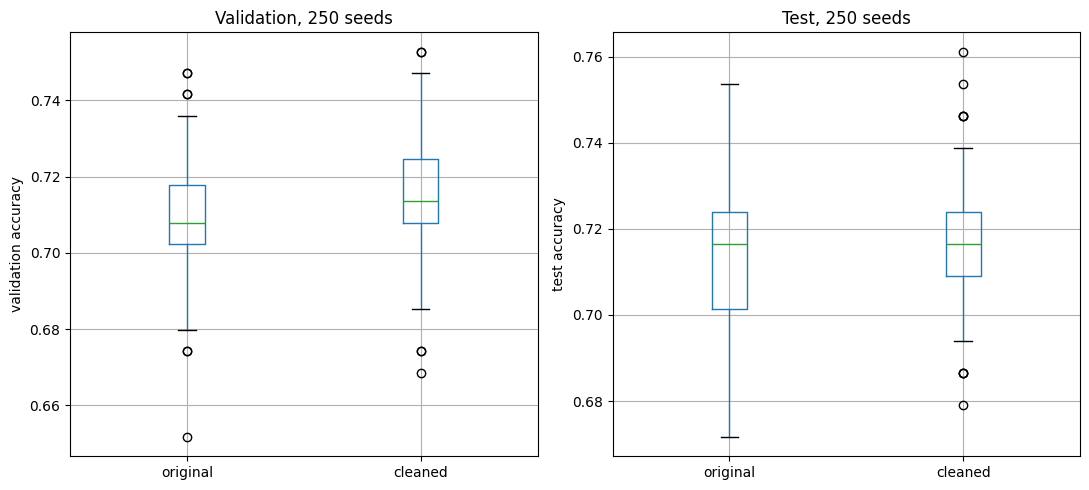

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
val_acc_df.boxplot(ax=axes[0])
axes[0].set_ylabel("validation accuracy")
axes[0].set_title(f"Validation, {N_SEEDS} seeds")
test_acc_df.boxplot(ax=axes[1])
axes[1].set_ylabel("test accuracy")
axes[1].set_title(f"Test, {N_SEEDS} seeds")
plt.tight_layout()
plt.show()

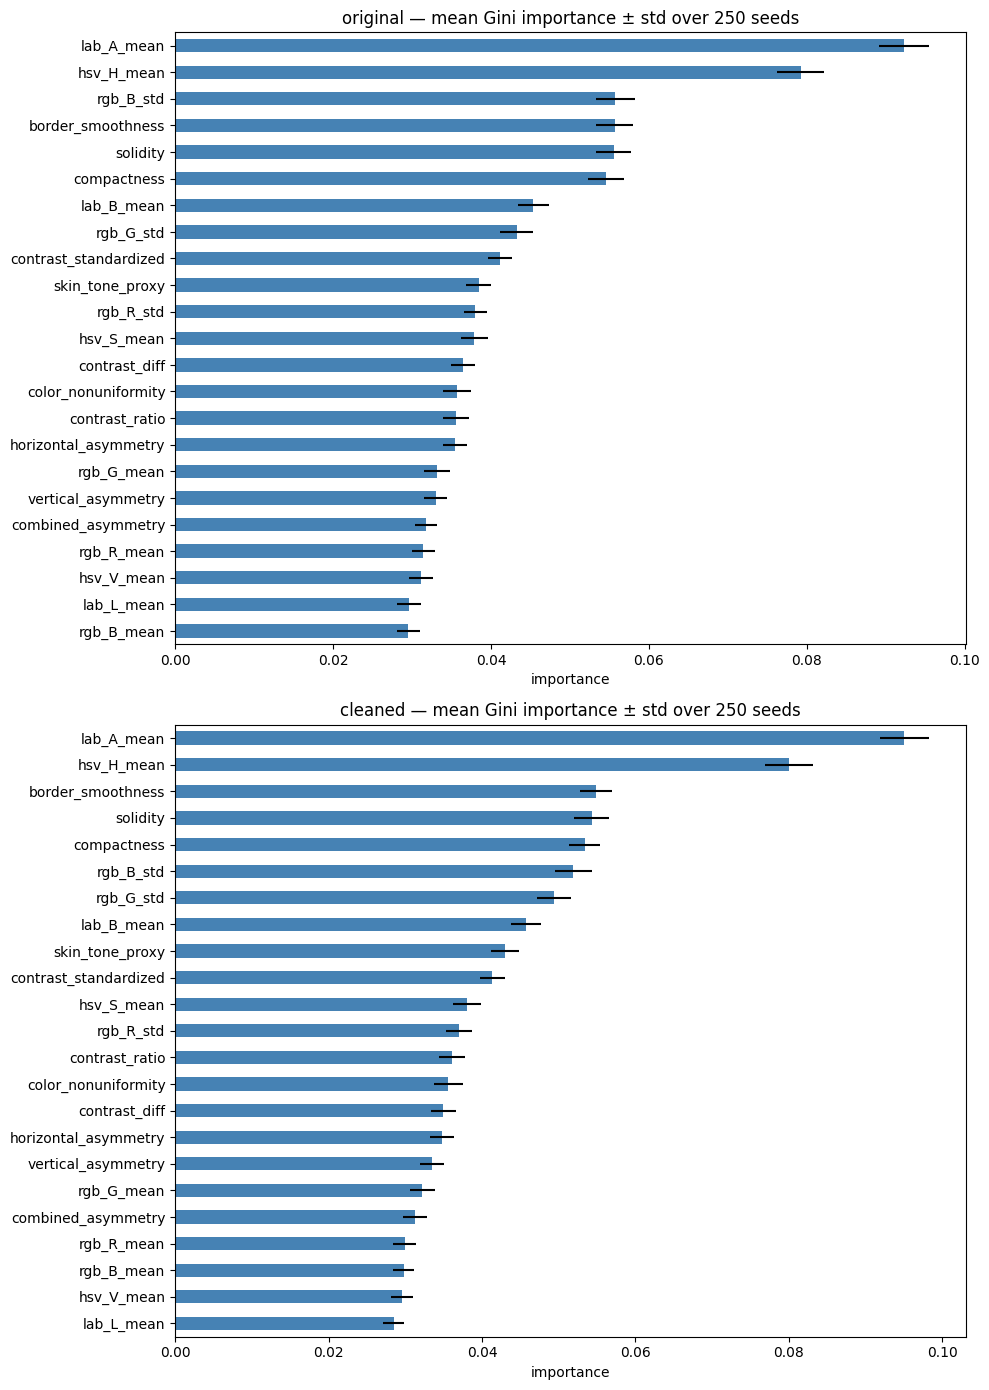

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 14))
for ax, (name, imp_df) in zip(axes, importance_dfs.items()):
    means = imp_df.mean().sort_values()
    stds  = imp_df.std().reindex(means.index)
    means.plot.barh(ax=ax, xerr=stds, color="steelblue", ecolor="black")
    ax.set_title(f"{name} — mean Gini importance ± std over {N_SEEDS} seeds")
    ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

In [16]:
# paired Wilcoxon: cleaned vs. original (baseline)
for split_name, df_res in [("validation", val_acc_df), ("test", test_acc_df)]:
    print(f"Paired Wilcoxon signed-rank test on {split_name} accuracy (vs. 'original'), n={N_SEEDS}:")
    print(f"  {'scenario':25s}  {'mean acc':>10s}  {'mean diff':>10s}  {'p-value':>10s}")
    for name in scenarios:
        mean_acc = df_res[name].mean()
        if name == "original":
            print(f"  {name:25s}  {mean_acc:>10.4f}  {'(baseline)':>10s}  {'':>10s}")
            continue
        diffs = df_res[name] - df_res["original"]
        stat, p = stats.wilcoxon(df_res[name], df_res["original"], zero_method="wilcox")
        print(f"  {name:25s}  {mean_acc:>10.4f}  {diffs.mean():>+10.4f}  {p:>10.32f}")
    print()

Paired Wilcoxon signed-rank test on validation accuracy (vs. 'original'), n=250:
  scenario                     mean acc   mean diff     p-value
  original                       0.7079  (baseline)            
  cleaned                        0.7137     +0.0058  0.00000610056288282777429049551568

Paired Wilcoxon signed-rank test on test accuracy (vs. 'original'), n=250:
  scenario                     mean acc   mean diff     p-value
  original                       0.7139  (baseline)            
  cleaned                        0.7149     +0.0010  0.46054865157270841180547904514242

